<a href="https://colab.research.google.com/github/umraodeepika7-dotcom/ctgan/blob/main/SDV_Synthesize_a_table_(Gaussian_Copula).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SDV Docs](https://docs.sdv.dev/sdv) > [Tutorials](https://docs.sdv.dev/sdv/tutorials)

# Synthesize a Table (Gaussian Coupla)

In this notebook, we'll use the SDV to create synthetic data for a single table and evaluate it. The SDV uses machine learning to learn patterns from real data and emulates them when creating synthetic data.

We'll use the **Gaussian Copula** algorithm to do this. Gaussian Copula is a fast, customizable and transparent way to synthesize data.

_Last Edit: January 30, 2026_

# 0. Installation

Install SDV Community.

In [2]:
%pip install sdv

In [1]:
!pip install table_evaluator

In [3]:
!pip install dython

  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
^C


# 1. Loading the demo data
For this demo, we'll use a fake dataset that describes some fictional guests staying at a hotel.

In [3]:
from google.colab import files
uploaded = files.upload()


Saving Pretreatment RS.csv to Pretreatment RS.csv


In [6]:
import pandas as pd
data = pd.read_csv('Pretreatment RS.csv')

In [7]:
real_data = pd.read_csv('Pretreatment RS.csv')

In [8]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=real_data)

In [9]:
display(real_data.head())

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,H2O,Original,0.60,0.00,0.61,1.25,1.00,3.17,0.30,0.00,0.88,0.00,0.09,31.67
1,H2O,Treated,0.68,0.00,0.58,1.07,0.94,2.66,0.24,0.00,0.92,0.00,0.00,22.24
2,H2SO4,Original,10.81,2.49,2.55,1.63,3.81,36.70,1.06,0.00,7.65,0.03,0.39,69.84
3,H2SO4,Treated,10.70,0.00,1.89,1.72,4.09,31.10,0.38,0.00,1.31,0.00,0.04,44.40
4,HCl,Original,37.26,4.55,0.66,11.18,5.97,66.37,1.83,0.28,5.46,0.00,0.16,74.64


In [10]:
categorical_features = ['Catalyst', 'samples', 'Xyl','Fur','Glu','Cel','Ara.','Total RS','EtOH','BuOH','Ace.','Prop.','n-But.','COD']

The demo also includes **metadata**, a description of the dataset. It includes the primary keys as well as the data types for each column (called "sdtypes").

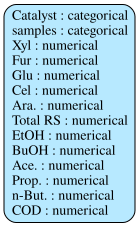

In [11]:
metadata.visualize()

In [16]:
from ctgan import CTGAN
import pandas as pd # Import pandas
ctgan = CTGAN(verbose=True)
ctgan.fit(real_data, categorical_features, epochs=80)

Gen. (+01.58) | Discrim. (-00.12): 100%|██████████| 80/80 [00:09<00:00,  8.64it/s]


# 2. Basic Usage

## 2.1 Creating a Synthesizer

An SDV **synthesizer** is an object that you can use to create synthetic data. It learns patterns from the real data and replicates them to generate synthetic data.

In [17]:
from sdv.single_table import GaussianCopulaSynthesizer

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(real_data)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


Now the synthesizer is ready to use!

## 2.2 Generating Synthetic Data

Use the `sample` function and pass in any number of rows to synthesize.

In [18]:
synthetic_data = synthesizer.sample(num_rows=500)
synthetic_data.head()

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,HCl,Original,29.38,3.95,2.55,7.26,5.36,63.29,1.34,0.0,7.59,0.0,0.37,65.09
1,HCl,Treated,12.34,0.01,1.26,4.56,2.05,27.90,0.49,0.0,4.85,0.0,0.32,34.85
2,HNO3,Original,25.99,0.01,0.59,7.90,6.73,62.12,0.94,0.0,1.13,0.0,0.07,77.07
3,H2SO4,Original,6.45,0.17,2.55,2.32,2.89,10.53,1.02,0.0,7.62,0.0,0.37,45.49
4,H2O,Original,7.77,0.10,0.36,3.39,5.74,5.99,0.27,0.0,0.70,0.0,0.04,73.92


In [21]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(synthetic_data)

,Catalyst,samples,Xyl,Fur,Glu,Cel,Ara.,Total RS,EtOH,BuOH,Ace.,Prop.,n-But.,COD
0,HCl,Original,29.38,3.95,2.55,7.26,5.36,63.29,1.34,0.00,7.59,0.00,0.37,65.09
1,HCl,Treated,12.34,0.01,1.26,4.56,2.05,27.90,0.49,0.00,4.85,0.00,0.32,34.85
2,HNO3,Original,25.99,0.01,0.59,7.90,6.73,62.12,0.94,0.00,1.13,0.00,0.07,77.07
3,H2SO4,Original,6.45,0.17,2.55,2.32,2.89,10.53,1.02,0.00,7.62,0.00,0.37,45.49
4,H2O,Original,7.77,0.10,0.36,3.39,5.74,5.99,0.27,0.00,0.70,0.00,0.04,73.92
5,H2O,Treated,3.76,0.00,0.36,2.85,5.67,19.29,0.36,0.00,0.55,0.00,0.20,70.77
6,HCl,Treated,5.73,0.00,1.20,2.31,1.75,4.61,0.30,0.00,3.69,0.00,0.22,30.17
7,H2O,Original,1.94,0.00,0.38,2.95,6.15,13.64,0.38,0.00,1.07,0.00,0.24,80.12
8,H2SO4,Original,29.88,4.50,1.96,9.55,6.73,65.99,1.12,0.28,7.20,0.00,0.37,82.72
9,H2SO4,Original,23.65,2.43,0.42,9.45,3.20,63.89,1.07,0.28,1.28,0.00,0.10,50.74


The synthesizer is generating synthetic guests in the **same format as the original data**.

## 2.3 Evaluating Real vs. Synthetic Data

SDV has built-in functions for evaluating the synthetic data and getting more insight.

As a first step, we can run a **diagnostic** to ensure that the data is valid. SDV's diagnostic performs some basic checks such as:

- All primary keys must be unique
- Continuous values must adhere to the min/max of the real data
- Discrete columns (non-PII) must have the same categories as the real data
- Etc.

In [22]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 14/14 [00:00<00:00, 632.50it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 165.91it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



<font color="green"><b>The score is 100%</b></font>, indicating that the data is fully valid.

We can also measure the **data quality** or the statistical similarity between the real and synthetic data. This value may vary anywhere from 0 to 100%.

In [23]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 725.04it/s]|
Column Shapes Score: 75.64%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 163.95it/s]|
Column Pair Trends Score: 64.87%

Overall Score (Average): 70.25%



The score tells us how similar the synthetic data is to the real data in terms of statistical patterns.

We can also get more details from the report. For example, the Column Shapes sub-score: Which columns had the highest vs. the lowest scores?

In [24]:
quality_report.get_details('Column Shapes')

,Column,Metric,Score
0,Catalyst,TVComplement,0.916
1,samples,TVComplement,0.928
2,Xyl,KSComplement,0.688
3,Fur,KSComplement,0.607
4,Glu,KSComplement,0.761
5,Cel,KSComplement,0.584
6,Ara.,KSComplement,0.760
7,Total RS,KSComplement,0.796
8,EtOH,KSComplement,0.770
9,BuOH,KSComplement,0.987


## 2.4 Visualizing the Data
For more insights, we can visualize the real vs. synthetic data.

Let's perform a 1D visualization comparing a column of the real data to the synthetic data.

In [26]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_name='Total RS',
    metadata=metadata
)

fig.show()


In [27]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_name='Catalyst',
    metadata=metadata
)

fig.show()

### Detailed Quality Report: Column Shapes

In [30]:
quality_report.get_details('Column Shapes')

,Column,Metric,Score
0,Catalyst,TVComplement,0.916
1,samples,TVComplement,0.928
2,Xyl,KSComplement,0.688
3,Fur,KSComplement,0.607
4,Glu,KSComplement,0.761
5,Cel,KSComplement,0.584
6,Ara.,KSComplement,0.760
7,Total RS,KSComplement,0.796
8,EtOH,KSComplement,0.770
9,BuOH,KSComplement,0.987


### Detailed Quality Report: Column Pair Trends

In [31]:
quality_report.get_details('Column Pair Trends')

,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,Catalyst,samples,ContingencySimilarity,NaN,NaN,NaN,0.000000,False
1,Catalyst,Xyl,ContingencySimilarity,0.186000,NaN,NaN,1.000000,True
2,Catalyst,Fur,ContingencySimilarity,0.524000,NaN,NaN,0.632456,True
3,Catalyst,Glu,ContingencySimilarity,0.210000,NaN,NaN,0.781736,True
4,Catalyst,Cel,ContingencySimilarity,0.214000,NaN,NaN,0.707107,True
5,Catalyst,Ara.,ContingencySimilarity,0.206000,NaN,NaN,0.912871,True
6,Catalyst,Total RS,ContingencySimilarity,0.288000,NaN,NaN,0.881917,True
7,Catalyst,EtOH,ContingencySimilarity,0.272000,NaN,NaN,0.881917,True
8,Catalyst,BuOH,ContingencySimilarity,0.773000,NaN,NaN,0.654654,True
9,Catalyst,Ace.,ContingencySimilarity,0.136000,NaN,NaN,0.881917,True


In [29]:
from sdv.evaluation.single_table import evaluate_quality

quality_report_overall = evaluate_quality(
    real_data,
    synthetic_data,
    metadata
)

print(f"Overall Quality Score: {quality_report_overall.get_score():.2f}%")

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 171.18it/s]|
Column Shapes Score: 75.64%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:01<00:00, 63.30it/s]|
Column Pair Trends Score: 64.87%

Overall Score (Average): 70.25%

Overall Quality Score: 0.70%


We can also visualize in 2D, comparing the correlations of a pair of columns.

In [28]:
from sdv.evaluation.single_table import get_column_pair_plot

fig = get_column_pair_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_names=['Xyl', 'Total RS'],
    metadata=metadata
)

fig.show()

In [33]:
!pip install shap

In [34]:
!pip install numpy

### Calculate SHAP values for Real Data ('Total RS')

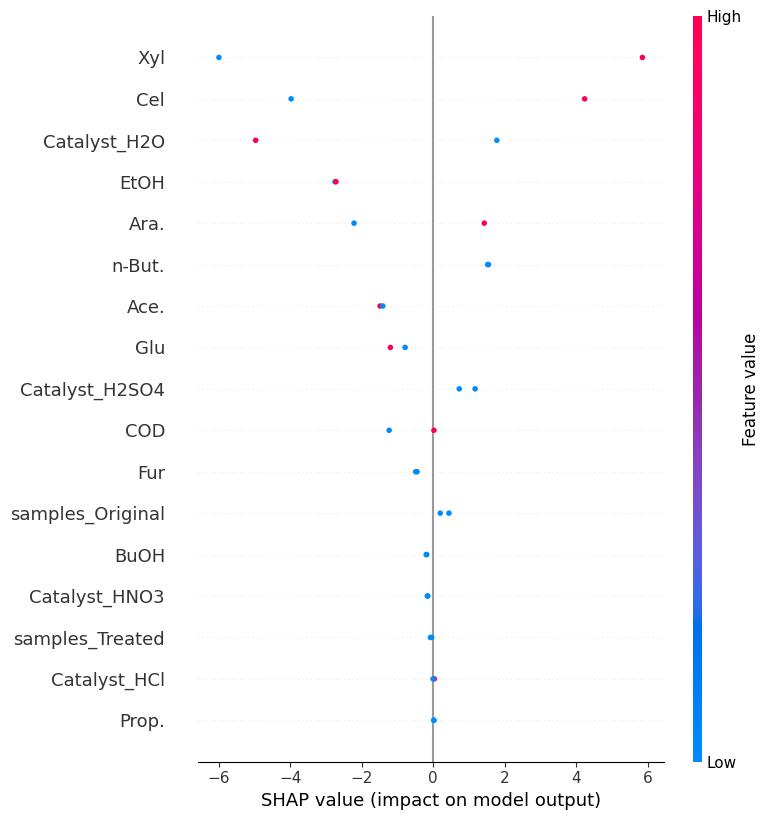

In [37]:
# Define features (X_real) and target (y_real) for real data
X_real = real_data.drop('Total RS', axis=1)
y_real = real_data['Total RS']

# Convert categorical features in X_real to numerical using one-hot encoding
X_real = pd.get_dummies(X_real, columns=['Catalyst', 'samples'])

# Split real data into training and testing sets
X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

# Train a RandomForestRegressor model on real data
model_real = RandomForestRegressor(n_estimators=100, random_state=42)
model_real.fit(X_real_train, y_real_train)

# Initialize SHAP explainer for the real data model
explainer_real = shap.TreeExplainer(model_real)

# Calculate SHAP values for the real test set
shap_values_real = explainer_real.shap_values(X_real_test)

# Visualize the SHAP values (summary plot) for real data
shap.summary_plot(shap_values_real, X_real_test)


This summary plot shows the importance of each feature in predicting 'Total RS' using the **real data**. You can now compare this with the previous SHAP summary plot generated using the **synthetic data** to see how well the synthetic data preserves feature importances.

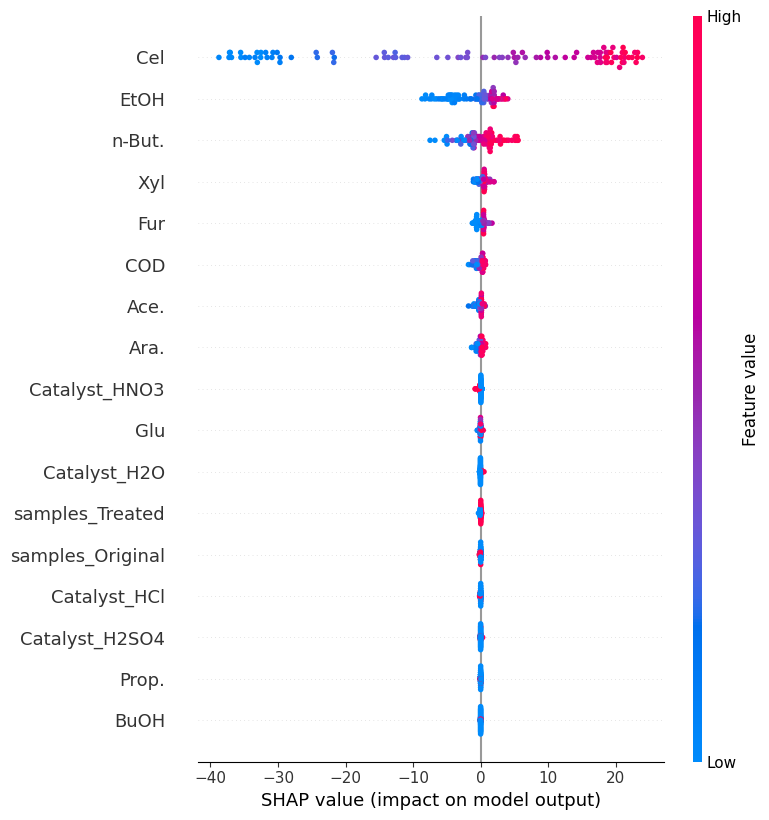

In [36]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import pandas as pd

# Define features (X) and new target (y)
X = synthetic_data.drop('Total RS', axis=1)
y = synthetic_data['Total RS']

# Convert categorical features in X to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['Catalyst', 'samples'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Visualize the SHAP values (summary plot)
shap.summary_plot(shap_values, X_test)


### Histogram Gradient Boosting

Histogram Gradient Boosting is a machine learning technique, often used for regression and classification tasks, known for its speed and performance on large datasets. It works by building an ensemble of decision trees, where each tree corrects the errors of the previous one. The "histogram" part refers to how it buckets continuous features into discrete bins (histograms), which significantly speeds up the training process without much loss in accuracy.

In [38]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Initialize and train a HistGradientBoostingRegressor model on the real data
hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_real_train, y_real_train)

# Make predictions on the real test set
y_real_pred = hgb_model.predict(X_real_test)

# Evaluate the model
mse = mean_squared_error(y_real_test, y_real_pred)
print(f"Mean Squared Error for HistGradientBoostingRegressor on real data: {mse:.2f}")

Mean Squared Error for HistGradientBoostingRegressor on real data: 975.56


### Visualize SHAP values for HistGradientBoostingRegressor

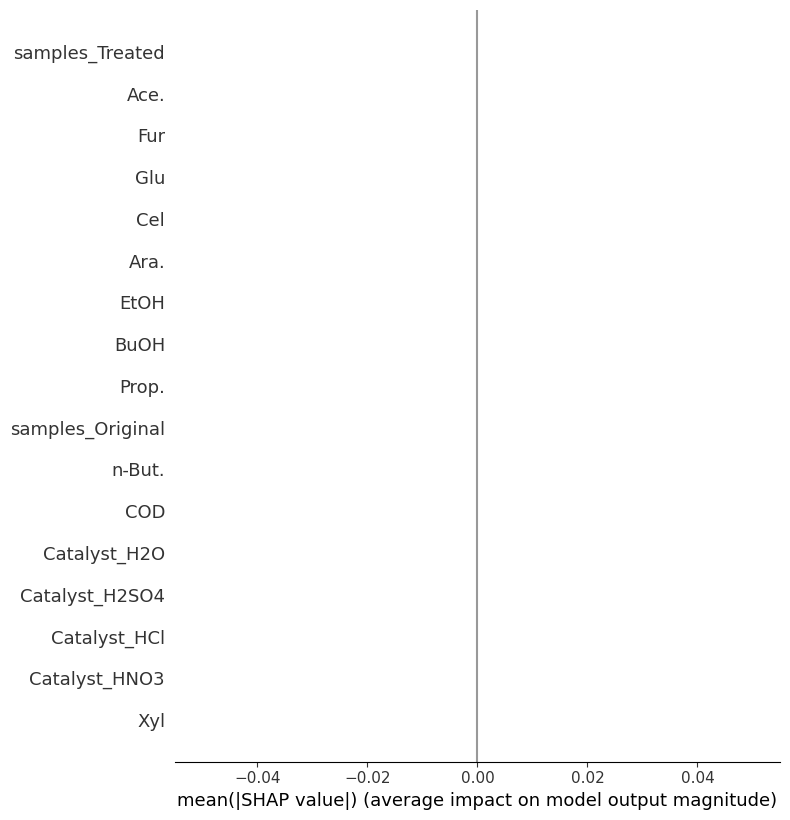

In [39]:
import shap

# Initialize SHAP explainer for the HistGradientBoostingRegressor model
# HistGradientBoostingRegressor is an ensemble tree model, so TreeExplainer is appropriate.
explainer_hgb = shap.TreeExplainer(hgb_model)

# Calculate SHAP values for the real test set
shap_values_hgb = explainer_hgb.shap_values(X_real_test)

# Visualize the SHAP values (summary plot) for the HistGradientBoostingRegressor model
shap.summary_plot(shap_values_hgb, X_real_test, plot_type="bar", max_display=len(X_real_test.columns))

This bar plot shows the mean absolute SHAP value for each feature, providing an overall understanding of which features are most important for the `HistGradientBoostingRegressor` model's predictions. Features are ranked by their importance, with the most impactful features at the top.

This summary plot shows the importance of each feature. Each point on the plot is a Shapley value for an instance and a feature. The position on the x-axis indicates the impact of that feature on the model's prediction. The color represents the feature's value (red for high, blue for low).

## 2.6 Saving and Loading
We can save the synthesizer to share with others and sample more synthetic data in the future.

In [ ]:
synthesizer.save('my_synthesizer.pkl')

In [ ]:
from sdv.utils import load_synthesizer

synthesizer = load_synthesizer('my_synthesizer.pkl')
synthesizer.sample(num_rows=3)

,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,cburns@example.com,False,SUITE,NaN,14 Jun 2020,23 Jun 2020,298.22,Unit 7909 Box 7283\nDPO AA 48458,30158284644887
1,jordanpamela@example.org,False,BASIC,0.04,26 Oct 2020,09 Nov 2020,244.69,"0837 Stewart Pike Suite 951\nPort Zachary, IA ...",4375705762878737
2,amanda33@example.org,False,DELUXE,35.96,10 Apr 2020,05 Apr 2020,176.64,"24644 Pollard Burgs Apt. 192\nSarahview, PA 78396",180027361090256


# 3. Gaussian Copula Customization

A key benefit of using the Gaussian Copula is **customization and transparency**. This synthesizer estimates the shape of every column using a 1D distribution. We can set these shapes ourselves.

In [ ]:
custom_synthesizer = GaussianCopulaSynthesizer(
    metadata,
    default_distribution='truncnorm',
    numerical_distributions={
        'checkin_date': 'uniform',
        'checkout_date': 'uniform',
        'room_rate': 'gaussian_kde'
    }
)

custom_synthesizer.fit(real_data)

After training, we can inspect the distributions. In this case, the synthesizer returns the parameter it learned using the truncnorm distribution.

<font color=navy><i>More information about truncnorm distribution is available in the [scipy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.truncnorm.html).</i></font>

In [ ]:
learned_distributions = custom_synthesizer.get_learned_distributions()
learned_distributions['has_rewards']

{'distribution': 'truncnorm',
 'learned_parameters': {'a': np.float64(-0.541500351405278),
  'b': np.float64(0.4646073535814237),
  'loc': np.float64(0.539063489790372),
  'scale': np.float64(0.9878956079482806)}}

By setting these distributions strategically, you can make tradeoffs in the quality of your synthetic data.

In [ ]:
synthetic_data_customized = custom_synthesizer.sample(num_rows=500)

quality_report = evaluate_quality(
    real_data,
    synthetic_data_customized,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 668.44it/s]|
Column Shapes Score: 93.4%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 426.21it/s]|
Column Pair Trends Score: 90.11%

Overall Score (Average): 91.76%



And we can verify this using the visualization functions.

In [ ]:
fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data_customized,
    column_name='room_rate',
    metadata=metadata
)

fig.show()

# 4. Conditional Sampling
Another benefit of using the Gaussian Copula is the ability to **efficiently sample conditions**. This allows us to simulate hypothetical scenarios.

Let's start by creating a scenario where every hotel guest is staying in a `SUITE` (half with rewards and half without).

In [ ]:
from sdv.sampling import Condition

suite_guests_with_rewards = Condition(
    num_rows=250,
    column_values={'room_type': 'SUITE', 'has_rewards': True}
)

suite_guests_without_rewards = Condition(
    num_rows=250,
    column_values={'room_type': 'SUITE', 'has_rewards': False}
)

Now we can simulate this scenario efficiently using our trained synthesizer.

In [ ]:
simulated_synthetic_data = custom_synthesizer.sample_from_conditions(conditions=[
  suite_guests_with_rewards,
  suite_guests_without_rewards
])

Sampling conditions: 100%|██████████| 500/500 [00:00<00:00, 977.32it/s]


We can verify this by plotting the data.

In [ ]:
fig = get_column_plot(
    real_data=real_data,
    synthetic_data=simulated_synthetic_data,
    column_name='room_type',
    metadata=metadata
)

fig.update_layout(
    title='Using synthetic data to simulate room_type scenario'
)

fig.show()

# 5. What's Next?

For more information about the Gaussian Copula Synthesizer, visit the **[documentation](https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/gaussiancopulasynthesizer)**.

⭐ To learn about other SDV features, [browse all tutorials](https://docs.sdv.dev/sdv/demos)

⭐ **Need more help?** [Visit our forum](https://forum.datacebo.com/) for troubleshooting, questions, or general feedback.

---

# About

The [Synthetic Data Vault Project](https://github.com/sdv-dev/SDV) was first created at MIT's Data to AI Lab in 2016. After 4 years of research and traction with enterprise, we created [DataCebo](https://datacebo.com/) in 2020 with the goal of growing the project. Today, DataCebo is the proud developer of SDV, the largest ecosystem for tabular synthetic data generation & evaluation.


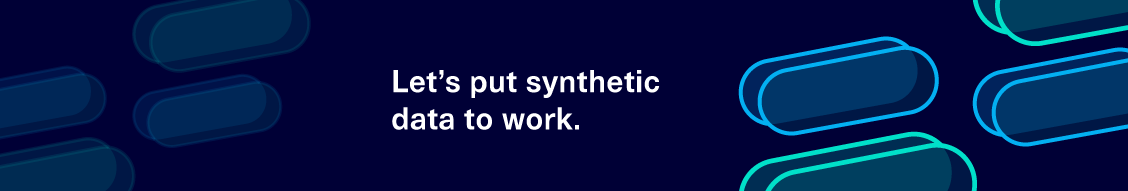